# Importing Libraries

In [3]:
import pandas as pd


# Load the CSV

In [4]:
df_whole= pd.read_csv("results_crop.csv")
df_whole

,crop_file,crop_file_path,image_id,Falsely identified,box_num,species,User_classified,same_species?,My analysis,common_name,...,user_class,order,user_order,family,user_family,genus,user_genus,score,top_no,topk_predictions_json
0,obs_10003229_photo_114145431_box1.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_10003229_photo_114145431,Match,1,Cerocala contraria,Eudocima divitiosa,False,NaN,NaN,...,Insecta,Lepidoptera,Lepidoptera,Erebidae,Erebidae,Cerocala,Eudocima,0.178396,1,"[{""species"": ""Cerocala contraria"", ""common_nam..."
1,obs_10003229_photo_114145431_box1.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_10003229_photo_114145431,Match,1,Chrysorithrum flavomaculata,Eudocima divitiosa,False,NaN,NaN,...,Insecta,Lepidoptera,Lepidoptera,Erebidae,Erebidae,Chrysorithrum,Eudocima,0.134323,2,"[{""species"": ""Cerocala contraria"", ""common_nam..."
2,obs_10003229_photo_114145431_box1.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_10003229_photo_114145431,Match,1,Ulotrichopus marmoratus,Eudocima divitiosa,False,NaN,NaN,...,Insecta,Lepidoptera,Lepidoptera,Erebidae,Erebidae,Ulotrichopus,Eudocima,0.066452,3,"[{""species"": ""Cerocala contraria"", ""common_nam..."
3,obs_10003229_photo_114145431_box1.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_10003229_photo_114145431,Match,1,Eudocima divitiosa,Eudocima divitiosa,True,NaN,NaN,...,Insecta,Lepidoptera,Lepidoptera,Erebidae,Erebidae,Eudocima,Eudocima,0.058108,4,"[{""species"": ""Cerocala contraria"", ""common_nam..."
4,obs_10003229_photo_114145431_box1.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_10003229_photo_114145431,Match,1,Eudocima colubra,Eudocima divitiosa,False,NaN,NaN,...,Insecta,Lepidoptera,Lepidoptera,Erebidae,Erebidae,Eudocima,Eudocima,0.032328,5,"[{""species"": ""Cerocala contraria"", ""common_nam..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
373725,obs_99990956_photo_166796345_box2.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_99990956_photo_166796345,No Match,2,Tauraco porphyreolophus,Gallirex porphyreolophus,False,NaN,Purple-crested Turaco,...,Aves,Musophagiformes,Musophagiformes,Musophagidae,Musophagidae,Tauraco,Gallirex,0.921519,1,"[{""species"": ""Tauraco porphyreolophus"", ""commo..."
373726,obs_99990956_photo_166796345_box2.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_99990956_photo_166796345,No Match,2,Tauraco hartlaubi,Gallirex porphyreolophus,False,NaN,Hartlaub's Turaco,...,Aves,Musophagiformes,Musophagiformes,Musophagidae,Musophagidae,Tauraco,Gallirex,0.019476,2,"[{""species"": ""Tauraco porphyreolophus"", ""commo..."
373727,obs_99990956_photo_166796345_box2.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_99990956_photo_166796345,No Match,2,Tauraco erythrolophus,Gallirex porphyreolophus,False,NaN,Red-crested Turaco,...,Aves,Musophagiformes,Musophagiformes,Musophagidae,Musophagidae,Tauraco,Gallirex,0.007151,3,"[{""species"": ""Tauraco porphyreolophus"", ""commo..."
373728,obs_99990956_photo_166796345_box2.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_99990956_photo_166796345,No Match,2,Tauraco fischeri,Gallirex porphyreolophus,False,NaN,Fischer's turaco,...,Aves,Musophagiformes,Musophagiformes,Musophagidae,Musophagidae,Tauraco,Gallirex,0.005640,4,"[{""species"": ""Tauraco porphyreolophus"", ""commo..."


# Helper Function

In [4]:
def find_ids(same,df):
    return df[df[same]== True]["image_id"].unique()
    


In [5]:
def category_accuracy(df_eval, category_match_col, category_col):
    print(f"{category_col} categories correctly identified:")
    true_count= df_eval[df_eval[category_match_col] == True].groupby(category_col)["image_id"].count()
    false_count= df_eval[df_eval[category_match_col] == False].groupby(category_col)["image_id"].count()
    total_count= df_eval.groupby(category_col)["image_id"].count()

    result = pd.DataFrame({
        "success_count": true_count,
        "failure_count": false_count,
        "total_count": total_count
    }).fillna(0)

    result["pct_success"] = ((result["success_count"] / result["total_count"]) * 100).round(2)
    result["pct_failure"] = ((result["failure_count"] / result["total_count"]) * 100).round(2)
    
    return result


# Setup df_whole

In [6]:
df_whole.info()

<class 'pandas.DataFrame'>
RangeIndex: 373730 entries, 0 to 373729
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   crop_file              373730 non-null  str    
 1   crop_file_path         373730 non-null  str    
 2   image_id               373730 non-null  str    
 3   Falsely identified     373730 non-null  str    
 4   box_num                373730 non-null  int64  
 5   species                373730 non-null  str    
 6   User_classified        373730 non-null  str    
 7   same_species?          373730 non-null  bool   
 8   My analysis            0 non-null       float64
 9   common_name            207329 non-null  str    
 10  kingdom                373730 non-null  str    
 11  user_kingdom           373730 non-null  str    
 12  phylum                 373312 non-null  str    
 13  user_phylum            373730 non-null  str    
 14  class                  356871 non-null  str    

In [7]:
df_whole["image_id"].unique()

<StringArray>
[ 'obs_10003229_photo_114145431', 'obs_100052837_photo_166933111',
 'obs_100052837_photo_166933119', 'obs_100052837_photo_166933123',
 'obs_100053359_photo_166934121', 'obs_100053359_photo_166934128',
 'obs_100053594_photo_166934121', 'obs_100053594_photo_166934128',
 'obs_100060648_photo_166948151', 'obs_100125424_photo_167070208',
 ...
  'obs_99913931_photo_166666359',  'obs_99913931_photo_166666388',
  'obs_99944557_photo_166725516',  'obs_99976381_photo_166788954',
  'obs_99990955_photo_166796294',  'obs_99990955_photo_166796310',
  'obs_99990955_photo_166796399',  'obs_99990955_photo_166796459',
  'obs_99990956_photo_166796339',  'obs_99990956_photo_166796345']
Length: 24803, dtype: str

In [29]:
df_whole_true = df_whole[df_whole["same_species?"]== True]
df_whole_true.isna().sum()

crop_file                    0
crop_file_path               0
image_id                     0
Falsely identified           0
box_num                      0
species                      0
User_classified              0
same_species?                0
My analysis              39177
common_name               7410
kingdom                      0
user_kingdom                 0
phylum                       0
user_phylum                  0
class                      672
user_class                   0
order                     2641
user_order                   0
family                       8
user_family                  0
genus                        0
user_genus                   0
score                        0
top_no                       0
topk_predictions_json        0
same_kingdom?                0
same_phylum?                 0
same_class?                  0
same_order?                  0
same_family?                 0
same_genus?                  0
dtype: int64

In [7]:
df_whole["same_kingdom?"]=df_whole.apply(lambda row: row['user_kingdom'] == row['kingdom'], axis=1)
df_whole["same_phylum?"]=df_whole.apply(lambda row: row['user_phylum'] == row['phylum'], axis=1)
df_whole["same_class?"]=df_whole.apply(lambda row: row['user_class'] == row['class'], axis=1)
df_whole["same_order?"]=df_whole.apply(lambda row: row['user_order'] == row['order'], axis=1)
df_whole["same_family?"]=df_whole.apply(lambda row: row['user_family'] == row['family'], axis=1)
df_whole["same_genus?"]=df_whole.apply(lambda row: row['user_genus'] == row['genus'], axis=1)
df_whole[["genus", "user_genus", "same_genus?"]]

,genus,user_genus,same_genus?
0,Cerocala,Eudocima,False
1,Chrysorithrum,Eudocima,False
2,Ulotrichopus,Eudocima,False
3,Eudocima,Eudocima,True
4,Eudocima,Eudocima,True
...,...,...,...
373725,Tauraco,Gallirex,False
373726,Tauraco,Gallirex,False
373727,Tauraco,Gallirex,False
373728,Tauraco,Gallirex,False


# New Eval DF with match values

In [8]:

df_eval = pd.DataFrame({
    "image_id": df_whole["image_id"].unique()
})

df_eval

,image_id
0,obs_10003229_photo_114145431
1,obs_100052837_photo_166933111
2,obs_100052837_photo_166933119
3,obs_100052837_photo_166933123
4,obs_100053359_photo_166934121
...,...
24798,obs_99990955_photo_166796310
24799,obs_99990955_photo_166796399
24800,obs_99990955_photo_166796459
24801,obs_99990956_photo_166796339


In [9]:
# true_df = df_whole[df_whole["same_species?"]== True]["image_id"].unique()
# true_df
df_eval["species_match"]= df_eval["image_id"].isin(find_ids("same_species?", df_whole))
df_eval[df_eval["species_match"]==False]



,image_id,species_match
1,obs_100052837_photo_166933111,False
2,obs_100052837_photo_166933119,False
3,obs_100052837_photo_166933123,False
4,obs_100053359_photo_166934121,False
5,obs_100053359_photo_166934128,False
...,...,...
24798,obs_99990955_photo_166796310,False
24799,obs_99990955_photo_166796399,False
24800,obs_99990955_photo_166796459,False
24801,obs_99990956_photo_166796339,False


In [10]:
df_eval["kingdom_match"]= df_eval["image_id"].isin(find_ids("same_kingdom?", df_whole))
df_eval["phylum_match"]= df_eval["image_id"].isin(find_ids("same_phylum?", df_whole))
df_eval["class_match"]= df_eval["image_id"].isin(find_ids("same_class?", df_whole))
df_eval["order_match"]= df_eval["image_id"].isin(find_ids("same_order?", df_whole))
df_eval["family_match"]= df_eval["image_id"].isin(find_ids("same_family?", df_whole))
df_eval["genus_match"]= df_eval["image_id"].isin(find_ids("same_genus?", df_whole))
# df_eval[df_eval["kingdom_match"]==False]
df_eval

,image_id,species_match,kingdom_match,phylum_match,class_match,order_match,family_match,genus_match
0,obs_10003229_photo_114145431,True,True,True,True,True,True,True
1,obs_100052837_photo_166933111,False,True,True,True,True,False,False
2,obs_100052837_photo_166933119,False,True,True,True,True,True,False
3,obs_100052837_photo_166933123,False,True,True,True,True,False,False
4,obs_100053359_photo_166934121,False,True,True,True,True,True,False
...,...,...,...,...,...,...,...,...
24798,obs_99990955_photo_166796310,False,True,True,True,True,True,True
24799,obs_99990955_photo_166796399,False,True,True,True,True,True,True
24800,obs_99990955_photo_166796459,False,True,True,True,True,True,True
24801,obs_99990956_photo_166796339,False,True,True,True,True,True,False


# Distribution of hierachical match

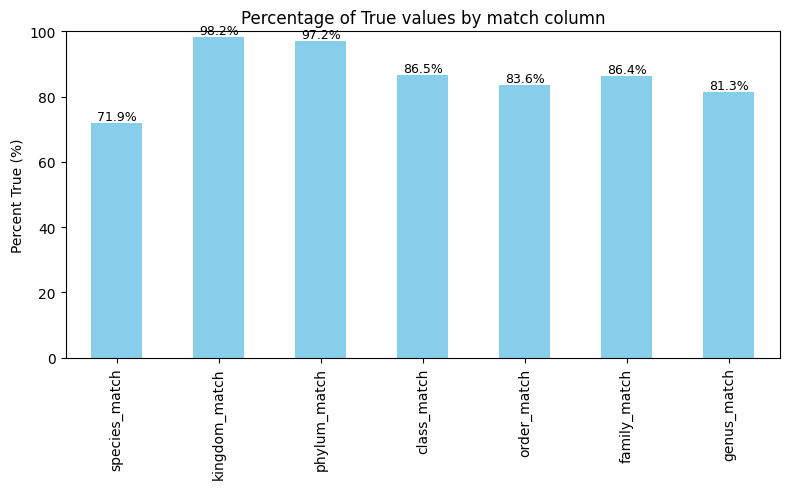

In [11]:
# Calculate percentage true per match column and plot
match_cols = [c for c in df_eval.columns if c.endswith("_match")]
percent_true = df_eval[match_cols].mean() * 100

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
percent_true.plot(kind="bar", ax=ax, color="skyblue")
ax.set_ylabel("Percent True (%)")
ax.set_title("Percentage of True values by match column")
ax.set_ylim(0, 100)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

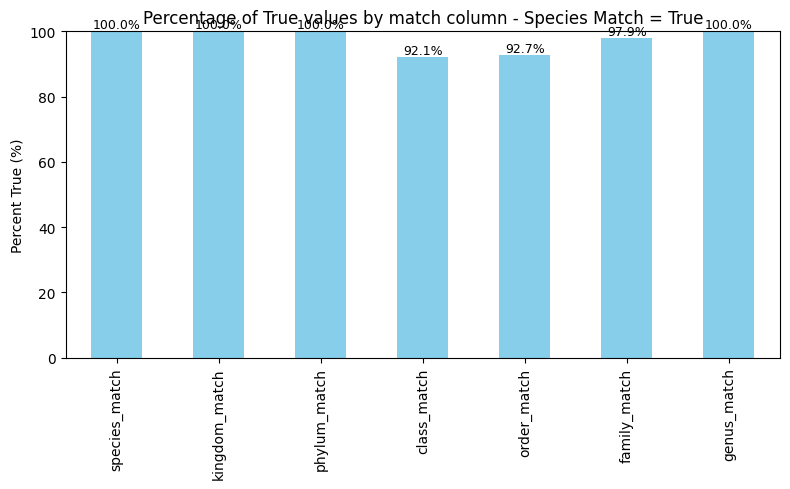

In [12]:
df_eval_true = df_eval[df_eval["species_match"]==True]
# Calculate percentage true per match column and plot
match_cols = [c for c in df_eval_true.columns if c.endswith("_match")]
percent_true = df_eval_true[match_cols].mean() * 100

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
percent_true.plot(kind="bar", ax=ax, color="skyblue")
ax.set_ylabel("Percent True (%)")
ax.set_title("Percentage of True values by match column - Species Match = True")
ax.set_ylim(0, 100)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

# Which category was rightly classified?

In [13]:
kingdom_map = df_whole.drop_duplicates("image_id").set_index("image_id")["user_kingdom"]
df_eval["kingdom"] = df_eval["image_id"].map(kingdom_map)
phylum_map = df_whole.drop_duplicates("image_id").set_index("image_id")["user_phylum"]
df_eval["phylum"] = df_eval["image_id"].map(phylum_map)
class_map = df_whole.drop_duplicates("image_id").set_index("image_id")["user_class"]
df_eval["class"] = df_eval["image_id"].map(class_map)
order_map = df_whole.drop_duplicates("image_id").set_index("image_id")["user_order"]
df_eval["order"] = df_eval["image_id"].map(order_map)
family_map = df_whole.drop_duplicates("image_id").set_index("image_id")["user_family"]
df_eval["family"] = df_eval["image_id"].map(family_map)
genus_map = df_whole.drop_duplicates("image_id").set_index("image_id")["user_genus"]
df_eval["genus"] = df_eval["image_id"].map(genus_map)
df_eval[["image_id", "kingdom", "phylum", "class", "order", "family", "genus"]]

,image_id,kingdom,phylum,class,order,family,genus
0,obs_10003229_photo_114145431,Animalia,Arthropoda,Insecta,Lepidoptera,Erebidae,Eudocima
1,obs_100052837_photo_166933111,Animalia,Chordata,Mammalia,Carnivora,Viverridae,Civettictis
2,obs_100052837_photo_166933119,Animalia,Chordata,Mammalia,Carnivora,Viverridae,Civettictis
3,obs_100052837_photo_166933123,Animalia,Chordata,Mammalia,Carnivora,Viverridae,Civettictis
4,obs_100053359_photo_166934121,Animalia,Chordata,Aves,Musophagiformes,Musophagidae,Crinifer
...,...,...,...,...,...,...,...
24798,obs_99990955_photo_166796310,Plantae,Tracheophyta,Magnoliopsida,Rosales,Moraceae,Ficus
24799,obs_99990955_photo_166796399,Plantae,Tracheophyta,Magnoliopsida,Rosales,Moraceae,Ficus
24800,obs_99990955_photo_166796459,Plantae,Tracheophyta,Magnoliopsida,Rosales,Moraceae,Ficus
24801,obs_99990956_photo_166796339,Animalia,Chordata,Aves,Musophagiformes,Musophagidae,Gallirex


In [14]:
kingdom = category_accuracy(df_eval, "kingdom_match", "kingdom")
print(kingdom)


kingdom categories correctly identified:
           success_count  failure_count  total_count  pct_success  pct_failure
kingdom                                                                       
Animalia         20136.0             57        20193        99.72         0.28
Bacteria             2.0              1            3        66.67        33.33
Chromista            4.0              1            5        80.00        20.00
Fungi              400.0             60          460        86.96        13.04
Plantae           3810.0            327         4137        92.10         7.90
Protozoa             0.0              4            4         0.00       100.00
Viruses              0.0              1            1         0.00       100.00


In [15]:
phylum = category_accuracy(df_eval, "phylum_match", "phylum")
print(phylum.sort_values("pct_success", ascending=False))

phylum categories correctly identified:
                     success_count  failure_count  total_count  pct_success  \
phylum                                                                        
Nemertea                       4.0            0.0            4       100.00   
Ochrophyta                     1.0            0.0            1       100.00   
Chordata                   11186.0           84.0        11270        99.25   
Arthropoda                  8393.0          185.0         8578        97.84   
Mollusca                     177.0           12.0          189        93.65   
Basidiomycota                 82.0            6.0           88        93.18   
Tracheophyta                3808.0          329.0         4137        92.05   
Onychophora                   34.0            4.0           38        89.47   
Ascomycota                   311.0           45.0          356        87.36   
Echinodermata                 45.0            7.0           52        86.54   
Cnidaria    

# Check the unmatch  in the same_species ones

## Unmatch class

In [ ]:

true_class_unmatch = df_whole_true[df_whole_true["same_class?"]== False]
true_class_unmatch[["image_id", "kingdom", "phylum", "user_class", "class", "species", "User_classified"]]
# true_class_unmatch

,image_id,kingdom,phylum,user_class,class,species,User_classified
695,obs_100598802_photo_167922439,Animalia,Chordata,Actinopterygii,NaN,Anguilla anguilla,Anguilla anguilla
704,obs_100598802_photo_167922531,Animalia,Chordata,Actinopterygii,NaN,Anguilla anguilla,Anguilla anguilla
717,obs_100598802_photo_167922551,Animalia,Chordata,Actinopterygii,NaN,Anguilla anguilla,Anguilla anguilla
1635,obs_100952210_photo_168541359,Animalia,Chordata,Reptilia,Squamata,Anolis sagrei,Anolis sagrei
1644,obs_100952316_photo_168541530,Animalia,Chordata,Reptilia,Squamata,Scincella lateralis,Scincella lateralis
...,...,...,...,...,...,...,...
372454,obs_98783065_photo_164544875,Animalia,Chordata,Actinopterygii,NaN,Anguilla anguilla,Anguilla anguilla
372672,obs_9884371_photo_13549400,Animalia,Chordata,Reptilia,Squamata,Regina grahamii,Regina grahamii
373583,obs_99913931_photo_166666388,Animalia,Chordata,Actinopterygii,NaN,Archosargus probatocephalus,Archosargus probatocephalus
373585,obs_99944557_photo_166725516,Animalia,Chordata,Reptilia,Squamata,Anolis sagrei,Anolis sagrei


In [30]:
true_class_unmatch.isna().sum()


crop_file                   0
crop_file_path              0
image_id                    0
Falsely identified          0
box_num                     0
species                     0
User_classified             0
same_species?               0
My analysis              3288
common_name               110
kingdom                     0
user_kingdom                0
phylum                      0
user_phylum                 0
class                     672
user_class                  0
order                    2641
user_order                  0
family                      0
user_family                 0
genus                       0
user_genus                  0
score                       0
top_no                      0
topk_predictions_json       0
same_kingdom?               0
same_phylum?                0
same_class?                 0
same_order?                 0
same_family?                0
same_genus?                 0
dtype: int64

In [31]:
true_class_unmatch_nonull = true_class_unmatch.dropna(subset=["class"])

In [ ]:
true_class_unmatch_nonull[["image_id", "kingdom", "phylum", "user_class", "class", "species", "User_classified"]]
# true_class_unmatch_nonull["class"].unique()
# true_class_unmatch_nonull.to_csv("unmatch_class_nonnull.csv", index=False)


In [52]:
temp_class = true_class_unmatch_nonull.drop_duplicates("species")
temp_class[["species","kingdom", "phylum", "class","user_class","order","family", "genus"]]
# .to_csv("unmatch_class.csv", index=False)

,species,kingdom,phylum,class,user_class,order,family,genus
1635,Anolis sagrei,Animalia,Chordata,Squamata,Reptilia,NaN,Dactyloidae,Anolis
1644,Scincella lateralis,Animalia,Chordata,Squamata,Reptilia,NaN,Scincidae,Scincella
2080,Hemidactylus mabouia,Animalia,Chordata,Squamata,Reptilia,NaN,Gekkonidae,Hemidactylus
3902,Chondrodactylus laevigatus,Animalia,Chordata,Squamata,Reptilia,NaN,Gekkonidae,Chondrodactylus
4580,Causus rhombeatus,Animalia,Chordata,Squamata,Reptilia,NaN,Viperidae,Causus
...,...,...,...,...,...,...,...,...
357786,Leiolepis belliana,Animalia,Chordata,Squamata,Reptilia,NaN,Agamidae,Leiolepis
363665,Hemidactylus bowringii,Animalia,Chordata,Squamata,Reptilia,NaN,Gekkonidae,Hemidactylus
368851,Agkistrodon contortrix,Animalia,Chordata,Squamata,Reptilia,NaN,Viperidae,Agkistrodon
369725,Anolis equestris,Animalia,Chordata,Squamata,Reptilia,NaN,Dactyloidae,Anolis


## unmatch order


In [42]:
true_order_unmatch = df_whole_true[df_whole_true["same_order?"]== False]
true_order_unmatch[["image_id", "kingdom", "phylum", "user_order", "order", "species", "User_classified"]]

,image_id,kingdom,phylum,user_order,order,species,User_classified
1580,obs_100876506_photo_168403528,Animalia,Arthropoda,Sarcoptiformes,Trombidiformes,Aculus tetanothrix,Aculus tetanothrix
1585,obs_100876506_photo_168403528,Animalia,Arthropoda,Sarcoptiformes,Trombidiformes,Aculus tetanothrix,Aculus tetanothrix
1590,obs_100876506_photo_168403528,Animalia,Arthropoda,Sarcoptiformes,Trombidiformes,Aculus tetanothrix,Aculus tetanothrix
1595,obs_100876506_photo_168403528,Animalia,Arthropoda,Sarcoptiformes,Trombidiformes,Aculus tetanothrix,Aculus tetanothrix
1600,obs_100876506_photo_168403538,Animalia,Arthropoda,Sarcoptiformes,Trombidiformes,Aculus tetanothrix,Aculus tetanothrix
...,...,...,...,...,...,...,...
372275,obs_98561205_photo_164123474,Animalia,Chordata,Squamata,NaN,Anolis sagrei,Anolis sagrei
372672,obs_9884371_photo_13549400,Animalia,Chordata,Squamata,NaN,Regina grahamii,Regina grahamii
373583,obs_99913931_photo_166666388,Animalia,Chordata,Acanthuriformes,Perciformes,Archosargus probatocephalus,Archosargus probatocephalus
373585,obs_99944557_photo_166725516,Animalia,Chordata,Squamata,NaN,Anolis sagrei,Anolis sagrei


In [43]:
true_order_unmatch_nonull = true_order_unmatch.dropna(subset=["order"])
true_order_unmatch_nonull[["image_id", "kingdom", "phylum", "user_order", "order", "species", "User_classified"]]

,image_id,kingdom,phylum,user_order,order,species,User_classified
1580,obs_100876506_photo_168403528,Animalia,Arthropoda,Sarcoptiformes,Trombidiformes,Aculus tetanothrix,Aculus tetanothrix
1585,obs_100876506_photo_168403528,Animalia,Arthropoda,Sarcoptiformes,Trombidiformes,Aculus tetanothrix,Aculus tetanothrix
1590,obs_100876506_photo_168403528,Animalia,Arthropoda,Sarcoptiformes,Trombidiformes,Aculus tetanothrix,Aculus tetanothrix
1595,obs_100876506_photo_168403528,Animalia,Arthropoda,Sarcoptiformes,Trombidiformes,Aculus tetanothrix,Aculus tetanothrix
1600,obs_100876506_photo_168403538,Animalia,Arthropoda,Sarcoptiformes,Trombidiformes,Aculus tetanothrix,Aculus tetanothrix
...,...,...,...,...,...,...,...
347375,obs_74889789_photo_122454838,Animalia,Chordata,Cathartiformes,Accipitriformes,Coragyps atratus,Coragyps atratus
367920,obs_93425371_photo_154836561,Animalia,Chordata,Cathartiformes,Accipitriformes,Cathartes aura,Cathartes aura
367925,obs_93425371_photo_154836561,Animalia,Chordata,Cathartiformes,Accipitriformes,Cathartes aura,Cathartes aura
367930,obs_93425371_photo_154836561,Animalia,Chordata,Cathartiformes,Accipitriformes,Cathartes aura,Cathartes aura


In [54]:
temp_order = true_order_unmatch_nonull.drop_duplicates("species")
temp_order[["species","kingdom", "phylum", "class","user_order","order","family", "genus"]]
# .to_csv("unmatch_order.csv", index=False)

,species,kingdom,phylum,class,user_order,order,family,genus
1580,Aculus tetanothrix,Animalia,Arthropoda,Arachnida,Sarcoptiformes,Trombidiformes,Eriophyidae,Aculus
2393,Balaenoptera borealis,Animalia,Chordata,Mammalia,Artiodactyla,Cetacea,Balaenopteridae,Balaenoptera
2404,Cynoscion nebulosus,Animalia,Chordata,NaN,Acanthuriformes,Perciformes,Sciaenidae,Cynoscion
3530,Coragyps atratus,Animalia,Chordata,Aves,Cathartiformes,Accipitriformes,Cathartidae,Coragyps
3580,Archosargus probatocephalus,Animalia,Chordata,NaN,Acanthuriformes,Perciformes,Sparidae,Archosargus
7456,Hypsypops rubicundus,Animalia,Chordata,NaN,Blenniiformes,Perciformes,Pomacentridae,Hypsypops
8407,Gibbonsia elegans,Animalia,Chordata,NaN,Blenniiformes,Perciformes,Clinidae,Gibbonsia
14125,Parophrys vetulus,Animalia,Chordata,NaN,Carangiformes,Pleuronectiformes,Pleuronectidae,Parophrys
17175,Cathartes aura,Animalia,Chordata,Aves,Cathartiformes,Accipitriformes,Cathartidae,Cathartes
19000,Lepomis macrochirus,Animalia,Chordata,NaN,Centrarchiformes,Perciformes,Centrarchidae,Lepomis


## unmatch_family

In [46]:
true_family_unmatch = df_whole_true[df_whole_true["same_family?"]== False]
true_family_unmatch[["image_id", "kingdom", "phylum", "user_family", "family", "species", "User_classified"]]

,image_id,kingdom,phylum,user_family,family,species,User_classified
1635,obs_100952210_photo_168541359,Animalia,Chordata,Anolidae,Dactyloidae,Anolis sagrei,Anolis sagrei
6046,obs_104115722_photo_174417618,Animalia,Chordata,Anolidae,Dactyloidae,Anolis sagrei,Anolis sagrei
6800,obs_104496023_photo_175102959,Animalia,Chordata,Cebidichthyidae,Stichaeidae,Cebidichthys violaceus,Cebidichthys violaceus
6805,obs_104496023_photo_175102963,Animalia,Chordata,Cebidichthyidae,Stichaeidae,Cebidichthys violaceus,Cebidichthys violaceus
6813,obs_104496023_photo_175102971,Animalia,Chordata,Cebidichthyidae,Stichaeidae,Cebidichthys violaceus,Cebidichthys violaceus
...,...,...,...,...,...,...,...
372265,obs_98561205_photo_164123474,Animalia,Chordata,Anolidae,Dactyloidae,Anolis sagrei,Anolis sagrei
372270,obs_98561205_photo_164123474,Animalia,Chordata,Anolidae,Dactyloidae,Anolis sagrei,Anolis sagrei
372275,obs_98561205_photo_164123474,Animalia,Chordata,Anolidae,Dactyloidae,Anolis sagrei,Anolis sagrei
373585,obs_99944557_photo_166725516,Animalia,Chordata,Anolidae,Dactyloidae,Anolis sagrei,Anolis sagrei


In [47]:
true_family_unmatch_nonull = true_family_unmatch.dropna(subset=["family"])
true_family_unmatch_nonull[["image_id", "kingdom", "phylum", "user_family", "family", "species", "User_classified"]]

,image_id,kingdom,phylum,user_family,family,species,User_classified
1635,obs_100952210_photo_168541359,Animalia,Chordata,Anolidae,Dactyloidae,Anolis sagrei,Anolis sagrei
6046,obs_104115722_photo_174417618,Animalia,Chordata,Anolidae,Dactyloidae,Anolis sagrei,Anolis sagrei
6800,obs_104496023_photo_175102959,Animalia,Chordata,Cebidichthyidae,Stichaeidae,Cebidichthys violaceus,Cebidichthys violaceus
6805,obs_104496023_photo_175102963,Animalia,Chordata,Cebidichthyidae,Stichaeidae,Cebidichthys violaceus,Cebidichthys violaceus
6813,obs_104496023_photo_175102971,Animalia,Chordata,Cebidichthyidae,Stichaeidae,Cebidichthys violaceus,Cebidichthys violaceus
...,...,...,...,...,...,...,...
372265,obs_98561205_photo_164123474,Animalia,Chordata,Anolidae,Dactyloidae,Anolis sagrei,Anolis sagrei
372270,obs_98561205_photo_164123474,Animalia,Chordata,Anolidae,Dactyloidae,Anolis sagrei,Anolis sagrei
372275,obs_98561205_photo_164123474,Animalia,Chordata,Anolidae,Dactyloidae,Anolis sagrei,Anolis sagrei
373585,obs_99944557_photo_166725516,Animalia,Chordata,Anolidae,Dactyloidae,Anolis sagrei,Anolis sagrei


In [55]:
temp_family = true_family_unmatch_nonull.drop_duplicates("species")
temp_family[["species","kingdom", "phylum", "class","order","user_family","family","genus"]]
# .to_csv("unmatch_family.csv", index=False)

,species,kingdom,phylum,class,order,user_family,family,genus
1635,Anolis sagrei,Animalia,Chordata,Squamata,NaN,Anolidae,Dactyloidae,Anolis
6800,Cebidichthys violaceus,Animalia,Chordata,NaN,Perciformes,Cebidichthyidae,Stichaeidae,Cebidichthys
13591,Gyas titanus,Animalia,Arthropoda,Arachnida,Opiliones,Phalangiidae,Sclerosomatidae,Gyas
15546,Thesium asterias,Plantae,Tracheophyta,Magnoliopsida,Santalales,Santalaceae,Thesiaceae,Thesium
15936,Brachycerus labrusca,Animalia,Arthropoda,Insecta,Coleoptera,Curculionidae,Brachyceridae,Brachycerus
...,...,...,...,...,...,...,...,...
359360,Cicindela oregona,Animalia,Arthropoda,Insecta,Coleoptera,Cicindelidae,Carabidae,Cicindela
359540,Delta fenestrale,Animalia,Arthropoda,Insecta,Hymenoptera,Vespidae,Eumenidae,Delta
361152,Trichonephila senegalensis,Animalia,Arthropoda,Arachnida,Araneae,Nephilidae,Araneidae,Trichonephila
368663,Dolomedes triton,Animalia,Arthropoda,Arachnida,Araneae,Dolomedidae,Pisauridae,Dolomedes


## Summary of results:

In [66]:
c_u = temp_class["class"].unique()
rows = []

for c in c_u:
    # print(f"Class: {c}")
    row = temp_class[temp_class["class"] == c][["class", "user_class"]].iloc[0]
    rows.append(row)

rows = pd.DataFrame(rows)
rows.sort_values("class")


,class,user_class
118945,Collembola,Entognatha
11900,Crocodylia,Reptilia
104041,Dictyochophyceae,Arachnida
22933,Elasmobranchii,Chondrichthyes
254760,Maxillopoda,Hexanauplia
1635,Squamata,Reptilia
18600,Testudines,Reptilia


In [67]:
o_u = temp_order["order"].unique()
rows = []

for c in o_u:
    # print(f"Class: {c}")
    row = temp_order[temp_order["order"] == c][["order", "user_order"]].iloc[0]
    rows.append(row)

rows = pd.DataFrame(rows)
rows.sort_values("order")


,order,user_order
3530,Accipitriformes,Cathartiformes
120200,Caprimulgiformes,Podargiformes
2393,Cetacea,Artiodactyla
94825,Enterobacterales,Enterobacteriales
164165,Erinaceomorpha,Eulipotyphla
42646,Esociformes,Salmoniformes
266750,Gasterosteiformes,Perciformes
104041,Pedinellales,Araneae
254760,Pedunculata,Pollicipedomorpha
2404,Perciformes,Acanthuriformes


In [69]:
f_u = temp_family["family"].unique()
rows = []

for c in f_u:
    # print(f"Class: {c}")
    row = temp_family[temp_family["family"] == c][["family", "user_family"]].iloc[0]
    rows.append(row)

rows = pd.DataFrame(rows)
rows.sort_values("family")


,family,user_family
18020,Araneidae,Nephilidae
15936,Brachyceridae,Curculionidae
291615,Bucorvidae,Bucerotidae
46395,Carabidae,Cicindelidae
22933,Carcharhinidae,Galeocerdonidae
67011,Cercopidae,Ischnorhinidae
68335,Clupeidae,Alosidae
60959,Cottidae,Psychrolutidae
101535,Cracticidae,Artamidae
257780,Cynipidae,Diplolepididae


In [ ]:
# df_whole[df_whole["species"]=="Entomobrya multifasciata"][["species","common_name", "class"]]

,species,common_name,class
72346,Entomobrya multifasciata,Springtail,Collembola
118945,Entomobrya multifasciata,Springtail,Collembola
118980,Entomobrya multifasciata,Springtail,Collembola
118985,Entomobrya multifasciata,Springtail,Collembola
118995,Entomobrya multifasciata,Springtail,Collembola
119007,Entomobrya multifasciata,Springtail,Collembola
119010,Entomobrya multifasciata,Springtail,Collembola
119015,Entomobrya multifasciata,Springtail,Collembola
119020,Entomobrya multifasciata,Springtail,Collembola
119035,Entomobrya multifasciata,Springtail,Collembola
